# Test DDH API Pagination Fix

The DDH API returns 100 records per page by default. Before the fix, `get_adm2_summaries` only returned the first page. This notebook verifies:

1. **Raw API**: `skip` parameter produces non-overlapping pages
2. **All 4 datasets (ARG)**: population, urbanization, nighttimelights, flood_exposure all paginate correctly
3. **Mapping**: Fetches ADM2 boundaries and creates choropleth maps for each dataset

In [30]:
import requests
import pandas as pd
import time

In [31]:
BASE_URL = "https://datacatalogapi.worldbank.org/ddhxext/v3/resources"
RESOURCE_ID = "DR0095354"  # population dataset
URL = f"{BASE_URL}/{RESOURCE_ID}/data"

## Step 1: Verify `skip` produces non-overlapping pages (raw API)

In [32]:
page1 = requests.get(URL, timeout=30).json()
page2 = requests.get(URL, params={"skip": 100}, timeout=30).json()

p1_ids = {r["ADM2CD_c"] for r in page1["value"]}
p2_ids = {r["ADM2CD_c"] for r in page2["value"]}

print(f"Total count reported by API: {page1['count']}")
print(f"Page 1: {len(page1['value'])} records")
print(f"Page 2: {len(page2['value'])} records")
print(f"Overlap: {len(p1_ids & p2_ids)}")
print(f"Combined unique: {len(p1_ids | p2_ids)}")
print(f"\nPage 1 last:  {page1['value'][-1]['ADM2CD_c']}")
print(f"Page 2 first: {page2['value'][0]['ADM2CD_c']}")

assert len(p1_ids & p2_ids) == 0, "Pages should not overlap!"
assert len(page1["value"]) == 100, "Default page size should be 100"
print("\n✓ skip parameter works correctly — no overlap between pages")

Total count reported by API: 38734
Page 1: 100 records
Page 2: 100 records
Overlap: 0
Combined unique: 200

Page 1 last:  AFG007011
Page 2 first: AFG008001

✓ skip parameter works correctly — no overlap between pages


## Step 2: Client — fetch all 4 datasets for Argentina

Argentina has 525 ADM2 units, requiring pagination across multiple pages.

In [33]:
from space2stats_client import Space2StatsClient

client = Space2StatsClient()

In [48]:
ISO3 = "KEN"
DATASETS = ["population", "urbanization", "nighttimelights", "flood_exposure"]

results = {}
for dataset in DATASETS:
    start = time.time()
    df = client.get_adm2_summaries(dataset, iso3_filter=ISO3)
    elapsed = time.time() - start
    results[dataset] = df
    n_dupes = df.duplicated(subset=["ADM2CD_c"]).sum()
    print(f"{dataset:20s} — {len(df):>4} records, {df['ADM2CD_c'].nunique()} unique, {n_dupes} dupes, {elapsed:.1f}s")
    assert n_dupes == 0, f"Duplicates found in {dataset}!"

print(f"\n✓ All 4 datasets returned data for {ISO3} with no duplicates")

Fetching population data from World Bank DDH API...
Filtering by ISO3: KEN
Retrieved 100 of 290 records...
Retrieved 200 of 290 records...
Retrieved 290 of 290 records...
population           —  290 records, 290 unique, 0 dupes, 2.4s
Fetching urbanization data from World Bank DDH API...
Filtering by ISO3: KEN
Retrieved 100 of 290 records...
Retrieved 200 of 290 records...
Retrieved 290 of 290 records...
urbanization         —  290 records, 290 unique, 0 dupes, 2.5s
Fetching nighttimelights data from World Bank DDH API...
Filtering by ISO3: KEN
Retrieved 100 of 290 records...
Retrieved 200 of 290 records...
Retrieved 290 of 290 records...
nighttimelights      —  290 records, 290 unique, 0 dupes, 2.8s
Fetching flood_exposure data from World Bank DDH API...
Filtering by ISO3: KEN
Retrieved 100 of 290 records...
Retrieved 200 of 290 records...
Retrieved 290 of 290 records...
flood_exposure       —  290 records, 290 unique, 0 dupes, 2.3s

✓ All 4 datasets returned data for KEN with no dupli

## Step 3: Fetch ADM2 boundaries and map results

In [49]:
import geopandas as gpd
import matplotlib.pyplot as plt

boundaries = client.fetch_admin_boundaries(ISO3, "ADM2", source="WB")
print(f"Boundaries: {len(boundaries)} ADM2 polygons")
print(f"Columns: {list(boundaries.columns)}")
boundaries.head()

Boundaries: 290 ADM2 polygons
Columns: ['FID', 'ISO_A3', 'ISO_A2', 'WB_A3', 'WB_REGION', 'WB_STATUS', 'NAM_0', 'NAM_1', 'ADM1CD_c', 'GEOM_SRCE', 'NAM_2', 'ADM2CD_c', 'GlobalID', 'Shape__Area', 'Shape__Length', 'geometry']


,FID,ISO_A3,ISO_A2,WB_A3,WB_REGION,WB_STATUS,NAM_0,NAM_1,ADM1CD_c,GEOM_SRCE,NAM_2,ADM2CD_c,GlobalID,Shape__Area,Shape__Length,geometry
0,8185,KEN,KE,KEN,AFR,Member State,Kenya,Siaya,KEN038,WB GAD,Alego Usonga,KEN038001,d8d6ae1c-c953-4e06-bd06-e628532b225d,0.049360,1.075194,"POLYGON ((34.04426 0.00804, 34.0621 0.07283, 3..."
1,8184,KEN,KE,KEN,AFR,Member State,Kenya,Nyeri,KEN036,WB GAD,Othaya,KEN036005,b5b92faa-80b4-402e-aea5-c3a14ed988e3,0.028962,0.986889,"POLYGON ((36.68517 -0.59753, 36.68228 -0.59097..."
2,8183,KEN,KE,KEN,AFR,Member State,Kenya,Nyeri,KEN036,WB GAD,Mukurweni,KEN036003,72f4a46f-5000-43da-a9be-2387b2b177bf,0.014526,0.630670,"POLYGON ((37.14504 -0.56074, 37.14384 -0.56608..."
3,8182,KEN,KE,KEN,AFR,Member State,Kenya,Nyandarua,KEN035,WB GAD,Kinangop,KEN035001,1d7e8d32-9afb-464d-99a9-049bab570f07,0.043789,1.323195,"POLYGON ((36.51209 -0.60892, 36.5121 -0.60783,..."
4,8181,KEN,KE,KEN,AFR,Member State,Kenya,Nyamira,KEN034,WB GAD,West Mugirango,KEN034004,d76be30e-510b-423c-8d2f-738ef94c0a6e,0.014615,0.628341,"POLYGON ((34.85897 -0.50244, 34.88117 -0.4858,..."


In [50]:
# Identify the join column in the boundaries GeoDataFrame
# The DDH data uses "ADM2CD_c" — find the matching code column in boundaries
boundary_cols = boundaries.columns.tolist()
print("Boundary columns:", boundary_cols)

# Try common code field names from WB ESRI service
join_col = None
for candidate in ["ADM2_PCODE", "WB_ADM2_CO", "ADM2CD_c", "ADM2_CODE", "shapeID"]:
    if candidate in boundary_cols:
        join_col = candidate
        break

if join_col is None:
    # Show sample values to help identify the right column
    print("\nSample boundary data (first 3 rows, non-geometry columns):")
    print(boundaries.drop(columns="geometry").head(3).to_string())
    raise ValueError("Could not auto-detect join column — check boundary columns above")

print(f"\nJoin column: {join_col}")
print(f"Sample values: {boundaries[join_col].head().tolist()}")

# Check how well the codes match
ddh_codes = set(results["population"]["ADM2CD_c"])
bnd_codes = set(boundaries[join_col])
matched = ddh_codes & bnd_codes
print(f"\nDDH codes: {len(ddh_codes)}, Boundary codes: {len(bnd_codes)}, Matched: {len(matched)}")
if len(matched) < len(ddh_codes):
    print(f"Unmatched DDH codes (first 5): {list(ddh_codes - bnd_codes)[:5]}")
    print(f"Unmatched boundary codes (first 5): {list(bnd_codes - ddh_codes)[:5]}")

Boundary columns: ['FID', 'ISO_A3', 'ISO_A2', 'WB_A3', 'WB_REGION', 'WB_STATUS', 'NAM_0', 'NAM_1', 'ADM1CD_c', 'GEOM_SRCE', 'NAM_2', 'ADM2CD_c', 'GlobalID', 'Shape__Area', 'Shape__Length', 'geometry']

Join column: ADM2CD_c
Sample values: ['KEN038001', 'KEN036005', 'KEN036003', 'KEN035001', 'KEN034004']

DDH codes: 290, Boundary codes: 290, Matched: 290


In [51]:
# The DDH API returns all values as strings — convert numeric columns first
for name, df in results.items():
    for col in df.columns:
        if col not in ("ADM2CD_c", "ISO3", "ADM2_NAME", "ADM2CD_f"):
            results[name][col] = pd.to_numeric(df[col], errors="coerce")

# Pick one representative numeric column per dataset for mapping
plot_cols = {}
for name, df in results.items():
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    print(f"\n{name} numeric columns ({len(numeric_cols)}):")
    print(f"  {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    
    # Heuristic: pick a "total" column if available, otherwise the last numeric column
    chosen = None
    for pattern in ["sum_pop_2020", "total", "mean", "sum_"]:
        matches = [c for c in numeric_cols if pattern in c.lower()]
        if matches:
            chosen = matches[-1]
            break
    if chosen is None:
        chosen = numeric_cols[-1] if numeric_cols else None
    
    plot_cols[name] = chosen
    print(f"  → selected: {chosen}")

print("\n\nColumns to map:")
for name, col in plot_cols.items():
    print(f"  {name:20s} → {col}")


population numeric columns (39):
  ['sum_pop_f_0_2020', 'sum_pop_f_10_2020', 'sum_pop_f_15_2020', 'sum_pop_f_1_2020', 'sum_pop_f_20_2020', 'sum_pop_f_25_2020', 'sum_pop_f_30_2020', 'sum_pop_f_35_2020', 'sum_pop_f_40_2020', 'sum_pop_f_45_2020']...
  → selected: sum_pop_2020

urbanization numeric columns (16):
  ['ghs_11_count', 'ghs_12_count', 'ghs_13_count', 'ghs_21_count', 'ghs_22_count', 'ghs_23_count', 'ghs_30_count', 'ghs_total_count', 'ghs_11_pop', 'ghs_12_pop']...
  → selected: ghs_total_pop

nighttimelights numeric columns (13):
  ['sum_viirs_ntl_2012', 'sum_viirs_ntl_2013', 'sum_viirs_ntl_2014', 'sum_viirs_ntl_2015', 'sum_viirs_ntl_2016', 'sum_viirs_ntl_2017', 'sum_viirs_ntl_2018', 'sum_viirs_ntl_2019', 'sum_viirs_ntl_2020', 'sum_viirs_ntl_2021']...
  → selected: sum_viirs_ntl_2024

flood_exposure numeric columns (3):
  ['pop', 'pop_flood', 'pop_flood_pct']
  → selected: pop_flood_pct


Columns to map:
  population           → sum_pop_2020
  urbanization         → ghs_total_po

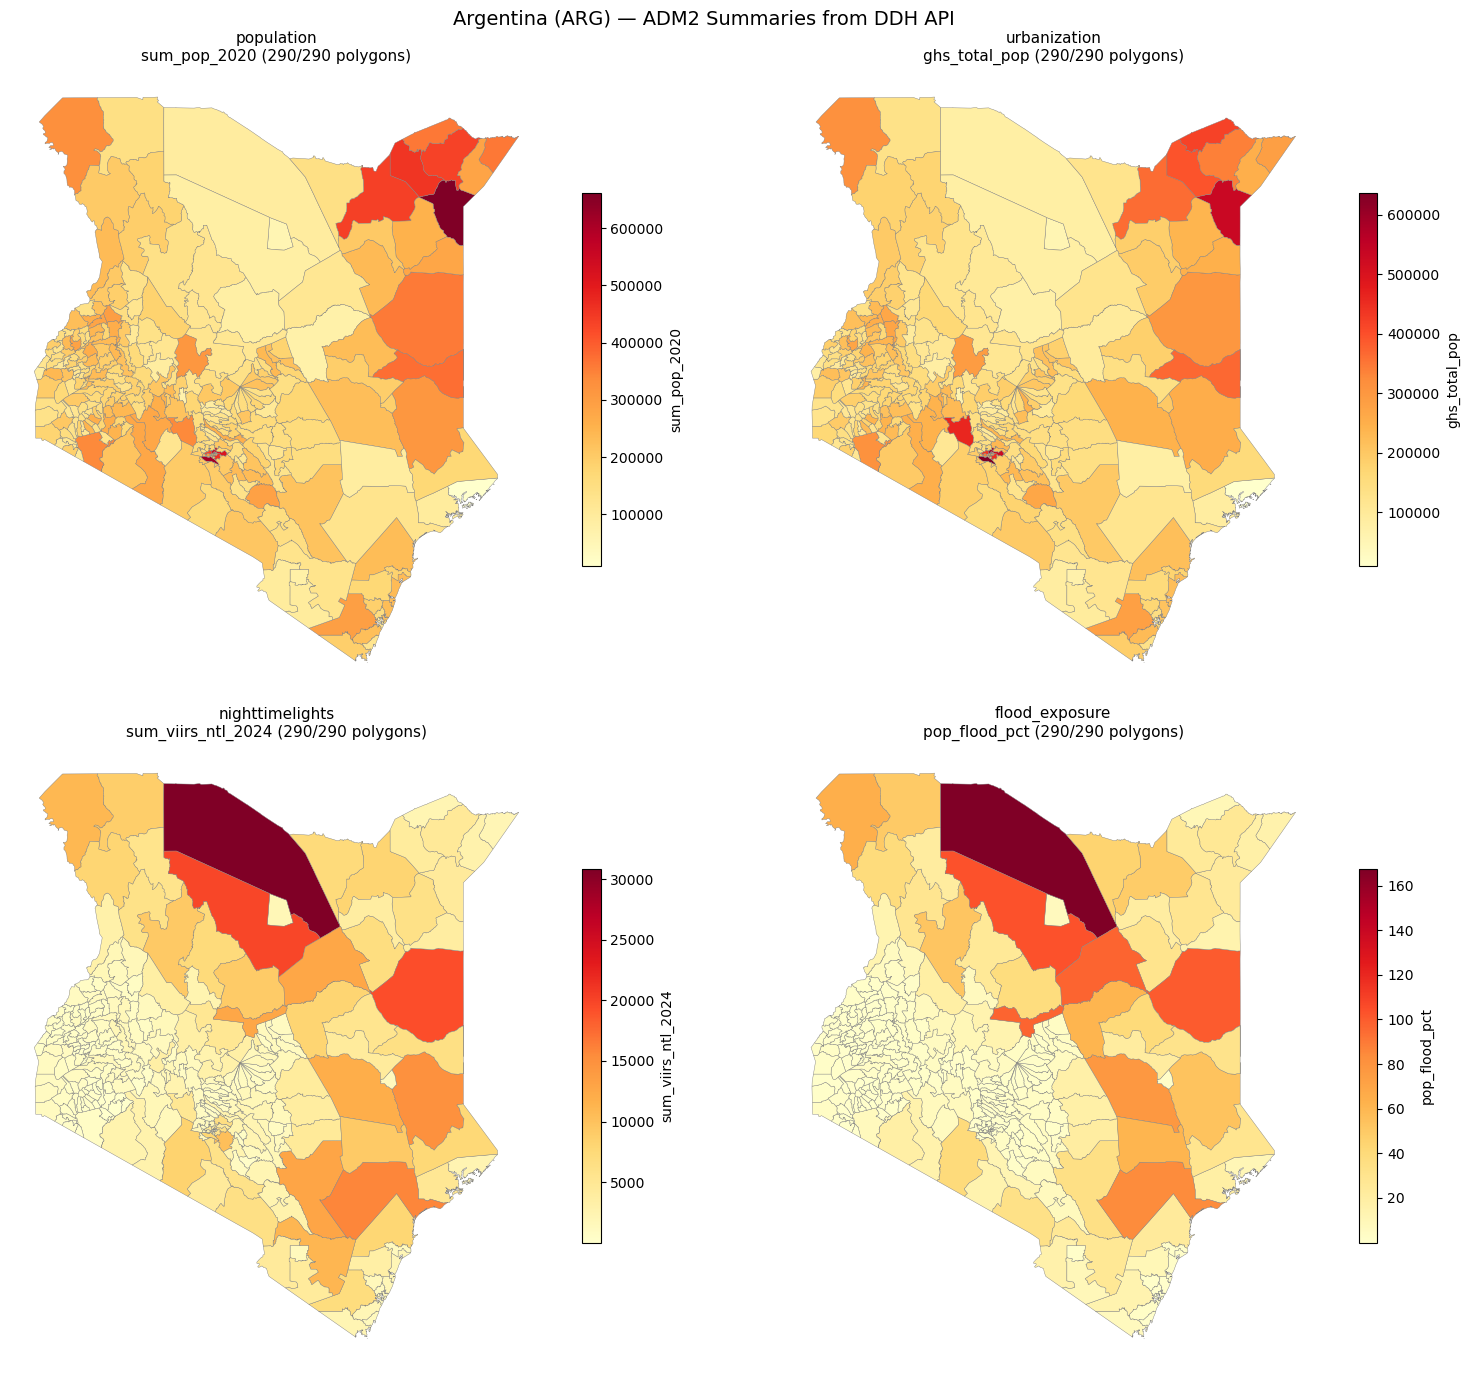

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (name, col) in zip(axes, plot_cols.items()):
    if col is None:
        ax.set_title(f"{name}\n(no numeric columns)")
        ax.axis("off")
        continue

    merged = boundaries.merge(
        results[name][["ADM2CD_c", col]],
        left_on=join_col,
        right_on="ADM2CD_c",
        how="left",
    )
    
    merged.plot(
        column=col,
        ax=ax,
        legend=True,
        legend_kwds={"shrink": 0.6, "label": col},
        missing_kwds={"color": "lightgrey", "label": "No data"},
        cmap="YlOrRd",
        edgecolor="0.5",
        linewidth=0.3,
    )
    
    n_with_data = merged[col].notna().sum()
    ax.set_title(f"{name}\n{col} ({n_with_data}/{len(merged)} polygons)", fontsize=11)
    ax.axis("off")

fig.suptitle(f"Argentina (ARG) — ADM2 Summaries from DDH API", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## Summary

| Test | Status |
|------|--------|
| Raw API `skip` parameter | Verified — non-overlapping pages |
| All 4 datasets for ARG | Verified — correct counts, no duplicates |
| ADM2 boundary fetch | Verified — polygons retrieved from WB ESRI |
| Choropleth maps | Verified — data joins to boundaries for all datasets |